# GRPO & RLVR for Code: Baseline vs MicroCoder-GRPO

## Motivation

**DeepSeek-R1** (2025) showed that training LLMs with purely verifiable rewards — no human labels, no reward model — produces strong reasoning through **RLVR** (RL with Verifiable Rewards). For math, the verifier is a symbolic checker. For code, it's the Python interpreter.

But GRPO breaks during RLVR training. Critically, code generation has **different failure modes** than math — longer outputs, faster capability growth, and changed training dynamics that math-derived fixes (DAPO) don't target.

**MicroCoder-GRPO** (Li et al., 2026 — arxiv 2603.07777) diagnosed code-specific failure modes and proposed three targeted fixes. This notebook implements and validates those fixes.

```
GRPO failure modes for code (diagnosed by MicroCoder-GRPO):
  1. Truncated good outputs penalised as failures  → Fix: Conditional Truncation Masking
  2. Policy diversity collapses mid-training       → Fix: Diversity-Determined Temperature
  3. KL penalty limits solution diversity          → Fix: No KL + High Clipping Ratio
```

## What this notebook answers

1. Does RLVR with unit-test rewards improve code generation (HumanEval pass@1)?
2. Do MicroCoder-GRPO's code-specific fixes improve over standard GRPO?
3. What do the training diagnostics reveal? (reward, entropy, output diversity)

| Stage | Method | Starting point |
|---|---|---|
| Baseline | GRPO (standard) | Qwen2.5-Coder-1.5B-Instruct |
| Full | GRPO + MicroCoder-GRPO fixes | Same checkpoint (fair comparison) |

**Hardware:** Colab Pro A100 (40GB). Full run: ~3 hours.  
**Reference:** MicroCoder-GRPO — arxiv 2603.07777

In [1]:
!pip install -q -U torchao
!pip install -q transformers datasets accelerate peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.2 MB/s eta 0:00:00


In [2]:
import ast, json, re, time, subprocess, random, textwrap
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Dict, Tuple

import torch
import torch.nn.functional as F
from torch.optim import AdamW
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# ── Config ────────────────────────────────────────────────────────────────────
BASE_MODEL = "Qwen/Qwen2.5-Coder-1.5B-Instruct"

# LoRA
LORA_R       = 8
LORA_ALPHA   = 16
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]

# GRPO shared
G              = 4      # completions per prompt per step
NUM_STEPS      = 200    # training steps each run
LR             = 1e-5
KL_COEFF       = 0.01
MAX_NEW_TOKENS = 256
MAX_PROMPT_LEN = 512
EVAL_EVERY     = 50     # real-exec check every N steps

# GRPO baseline
EPSILON = 0.2

# MicroCoder-GRPO specific (arxiv 2603.07777)
EPSILON_HIGH_MC  = 0.5   # Fix 3: high upper clip replaces KL as diversity driver
MASK_PROB        = 0.3   # Fix 1: ρ — probability to mask truncated non-repetitive outputs
REPEAT_CHECK_LEN = 128   # Fix 1: tokens used for repetition check (last m vs preceding m)
TEMP_STAGE1      = 0.7   # Fix 2: generation temperature for steps 0 → TEMP_SWITCH_STEP
TEMP_STAGE2      = 1.0   # Fix 2: generation temperature after TEMP_SWITCH_STEP
TEMP_SWITCH_STEP = 100   # Fix 2: step at which temperature is raised

MBPP_TRAIN_N  = 150     # MBPP problems used for RL training
MBPP_EVAL_N   = 30      # held-out MBPP problems for mid-training real-exec check

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB


---
## Section 1 — Base Model + HumanEval Harness

Measure the starting point before any RL. This is the number everything else is compared against.

In [3]:
# ── Load tokenizer (shared across all stages) ─────────────────────────────────

print(f"Loading tokenizer: {BASE_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"


# ── HumanEval loader + execution harness ──────────────────────────────────────

humaneval = load_dataset("openai/openai_humaneval", split="test")
print(f"HumanEval: {len(humaneval)} problems")


def run_humaneval_solution(prompt: str, completion: str,
                            test: str, entry_point: str,
                            timeout: int = 5) -> bool:
    completion = re.sub(r'```(?:python)?\s*\n?|```', '', completion).strip()
    code = prompt + "\n" + completion + "\n\n" + test + f"\n\ncheck({entry_point})"
    try:
        r = subprocess.run(["python3", "-c", code],
                           capture_output=True, text=True, timeout=timeout)
        return r.returncode == 0
    except Exception:
        return False


def evaluate_humaneval(model, tokenizer, problems,
                        max_new_tokens: int = 512) -> Dict:
    """Greedy pass@1 on all HumanEval problems."""
    model.eval()
    passed_ids, results = [], []

    for p in tqdm(problems, desc="HumanEval eval"):
        messages = [
            {"role": "system", "content": "Complete the Python function. Write ONLY the function body. No markdown, no code fences."},
            {"role": "user",   "content": f"Complete this function:\n\n{p['prompt']}"}
        ]
        prompt_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(prompt_text, return_tensors="pt",
                           truncation=True, max_length=1024).to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
        completion = tokenizer.decode(
            out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True
        ).strip()

        ok = run_humaneval_solution(
            p["prompt"], completion, p["test"], p["entry_point"]
        )
        results.append({"task_id": p["task_id"], "passed": ok, "completion": completion})
        if ok:
            passed_ids.append(p["task_id"])

    pass_at_1 = len(passed_ids) / len(problems)
    return {"pass@1": pass_at_1, "passed": passed_ids, "results": results}

Loading tokenizer: Qwen/Qwen2.5-Coder-1.5B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.52k [00:00<?, ?B/s]

openai_humaneval/test-00000-of-00001.par(…):   0%|          | 0.00/83.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

HumanEval: 164 problems


In [4]:
# ── Load base model + measure baseline ────────────────────────────────────────

print(f"Loading {BASE_MODEL}...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=dtype, device_map="auto"
)
n_params = sum(p.numel() for p in base_model.parameters()) / 1e6
print(f"Loaded: {n_params:.0f}M parameters")

print("\nEvaluating BASE model on HumanEval...")
base_eval = evaluate_humaneval(base_model, tokenizer, humaneval)
print(f"\nBase  pass@1 = {base_eval['pass@1']:.3f}  "
      f"({len(base_eval['passed'])}/{len(humaneval)})")

# Free base model — reload with LoRA for training
del base_model
torch.cuda.empty_cache()
print("\nBase model freed — ready for RL training.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading Qwen/Qwen2.5-Coder-1.5B-Instruct...


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: 1544M parameters

Evaluating BASE model on HumanEval...


HumanEval eval: 100%|██████████| 164/164 [06:41<00:00,  2.45s/it]


Base  pass@1 = 0.622  (102/164)

Base model freed — ready for RL training.


---
## Section 2 — RLVR: GRPO Baseline

Standard GRPO with partial execution rewards. No MicroCoder-GRPO fixes yet.

**Reward signal:** Run each MBPP test case individually via Python subprocess.  
`reward = tests_passed / total_tests`  
This is **verifiable** — no reward model, no human labels, just the interpreter.  
Partial credit (0.33, 0.67, 1.0) matters: it creates reward variance within the G=4 group even when no completion fully passes all tests, giving GRPO a gradient signal from the start of training. Pure binary pass/fail (0 or 1) collapses to zero gradient whenever the model fails every test.

**Training signal:** We track three diagnostics that reveal GRPO's failure modes:
- **Mean reward** — is the policy learning to pass tests?
- **Reward std per group** — if this is near 0, there's no gradient signal (all completions identical reward)
- **Policy entropy** — if this collapses, the model has mode-collapsed

In [5]:
# ── Load MBPP for RL training ──────────────────────────────────────────────────

print("Loading MBPP...")
mbpp_raw = load_dataset("google-research-datasets/mbpp", "sanitized", split="train")
all_problems = [
    {"text": mbpp_raw[i]["prompt"], "tests": mbpp_raw[i]["test_list"]}
    for i in range(len(mbpp_raw))
]
print(f"MBPP sanitized train: {len(all_problems)} problems available")

n = len(all_problems)
assert n > MBPP_EVAL_N, f"Dataset too small: {n} problems, need at least {MBPP_EVAL_N+1}"
train_end      = min(MBPP_TRAIN_N, n - MBPP_EVAL_N)
train_problems = all_problems[:train_end]
eval_problems  = all_problems[train_end : train_end + MBPP_EVAL_N]
print(f"Train: {len(train_problems)}  |  Eval: {len(eval_problems)}")


# ── Reward function ────────────────────────────────────────────────────────────

def execution_reward(code: str, tests: List[str], timeout: int = 5) -> float:
    """
    Partial test reward: fraction of individual tests passed.
    Syntax errors return 0.0. Each test is run independently so a completion
    that passes 1/3 tests gets 0.33 — not 0.0 like binary pass/fail would give.
    This creates variance within the G-group even when no completion fully passes,
    giving GRPO a gradient signal from the start of training.
    """
    code = re.sub(r'```(?:python)?\s*\n?|```', '', code).strip()
    try:
        ast.parse(code)
    except SyntaxError:
        return 0.0

    if not tests:
        return 0.0

    passed = 0
    for test in tests:
        try:
            full = code + "\n\n" + test
            r = subprocess.run(["python3", "-c", full],
                               capture_output=True, text=True, timeout=timeout)
            if r.returncode == 0:
                passed += 1
        except Exception:
            pass

    return passed / len(tests)


# ── Function name extractor ───────────────────────────────────────────────────

def get_function_name(tests: List[str]) -> str:
    """Parse the expected function name from MBPP test assertions.

    MBPP tests look like: assert fibonacci(10) == 55
    Without telling the model the function name, it generates wrong names → NameError → 0 reward.
    """
    for test in tests:
        m = re.search(r'\bassert\s+(\w+)\s*\(', test)
        if m:
            return m.group(1)
    return ""


# ── Prompt formatter ──────────────────────────────────────────────────────────

def format_code_prompt(tokenizer, problem_text: str, function_name: str = "") -> str:
    sys_content = "You are an expert Python programmer. Write ONLY the Python function. No markdown, no code fences, no explanations."
    if function_name:
        sys_content += f" The function must be named `{function_name}`."
    messages = [
        {"role": "system", "content": sys_content},
        {"role": "user",   "content": f"Solve this Python task:\n\n{problem_text}"}
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


# ── Generation helper ─────────────────────────────────────────────────────────

def generate_completions(
    model, tokenizer, problem_text: str,
    G: int = 4, temperature: float = 0.8,
    function_name: str = "",
) -> Tuple[List[str], List[torch.Tensor], torch.Tensor]:
    prompt = format_code_prompt(tokenizer, problem_text, function_name)
    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=MAX_PROMPT_LEN
    ).to(model.device)
    prompt_len = inputs.input_ids.shape[1]

    greedy = temperature == 0.0
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=not greedy,
            temperature=temperature if not greedy else None,
            num_return_sequences=G,
            pad_token_id=tokenizer.eos_token_id,
        )

    comp_ids = [out[i, prompt_len:].cpu() for i in range(G)]
    texts    = [tokenizer.decode(ids, skip_special_tokens=True).strip() for ids in comp_ids]
    return texts, comp_ids, inputs.input_ids.cpu()

Loading MBPP...


README.md:   0%|          | 0.00/9.06k [00:00<?, ?B/s]

sanitized/train-00000-of-00001.parquet:   0%|          | 0.00/33.9k [00:00<?, ?B/s]

sanitized/test-00000-of-00001.parquet:   0%|          | 0.00/60.9k [00:00<?, ?B/s]

sanitized/validation-00000-of-00001.parq(…):   0%|          | 0.00/14.0k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/257 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/43 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/7 [00:00<?, ? examples/s]

MBPP sanitized train: 120 problems available
Train: 90  |  Eval: 30


In [6]:
# ── GRPO core functions ───────────────────────────────────────────────────────

def get_log_probs(model, prompt_ids: torch.Tensor,
                  comp_ids: torch.Tensor) -> torch.Tensor:
    """Per-token log probs of comp_ids given prompt_ids. Returns [comp_len] tensor."""
    dev   = next(model.parameters()).device
    p_ids = prompt_ids.to(dev)
    c_ids = comp_ids.to(dev)

    if len(c_ids) == 0:
        return torch.tensor([-10.0], device=dev)

    ids       = torch.cat([p_ids, c_ids.unsqueeze(0)], dim=1)
    logits    = model(input_ids=ids).logits[0]
    plen      = p_ids.shape[1]
    log_probs = F.log_softmax(logits[plen - 1 : -1], dim=-1)
    return log_probs[torch.arange(len(c_ids)), c_ids]


def compute_kl(lp: torch.Tensor, ref_lp: torch.Tensor) -> torch.Tensor:
    """Unbiased KL(policy || ref): E[exp(ref-pi) - (ref-pi) - 1]"""
    diff = ref_lp.detach() - lp
    return (torch.exp(diff) - diff - 1).mean()


def compute_entropy(lp: torch.Tensor) -> torch.Tensor:
    return -lp.mean()


# ── GRPO loss (baseline — symmetric clipping, sequence-level normalisation) ───

def compute_grpo_loss(
    lp_list:     List[torch.Tensor],
    old_lp_list: List[torch.Tensor],
    advantages:  torch.Tensor,
    epsilon:     float = 0.2,
) -> torch.Tensor:
    losses = []
    for lp, old_lp, adv in zip(lp_list, old_lp_list, advantages):
        ratio     = torch.exp(lp.mean() - old_lp.detach().mean())
        unclipped = ratio * adv
        clipped   = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * adv
        losses.append(-torch.minimum(unclipped, clipped))
    return torch.stack(losses).mean()


# ── MicroCoder-GRPO helpers (arxiv 2603.07777) ───────────────────────────────

def compute_ngram_diversity(texts: List[str], n: int = 4) -> float:
    """4-gram diversity: unique n-grams / total n-grams across all G completions."""
    all_ngrams, unique_ngrams = [], set()
    for text in texts:
        words  = text.split()
        ngrams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
        all_ngrams.extend(ngrams)
        unique_ngrams.update(ngrams)
    return len(unique_ngrams) / len(all_ngrams) if all_ngrams else 1.0


def is_repetitive(comp_ids: torch.Tensor, m: int = 128) -> bool:
    """True if the last m tokens exactly repeat the preceding m tokens."""
    if len(comp_ids) < 2 * m:
        return False
    return comp_ids[-m:].tolist() == comp_ids[-2*m:-m].tolist()


def compute_microcoder_loss(
    lp_list:     List[torch.Tensor],
    old_lp_list: List[torch.Tensor],
    advantages:  torch.Tensor,
    eps_low:     float = 0.2,
    eps_high:    float = 0.5,
) -> torch.Tensor:
    """
    MicroCoder-GRPO loss — 3 code-specific fixes (arxiv 2603.07777):

    Fix 1 — Conditional Truncation Masking:
      Applied to advantages before this call (in training loop).
      Truncated non-repetitive outputs get advantage=0 so they are not
      penalised as failures — they may be correct but cut off at max length.

    Fix 2 — Diversity-Determined Temperature:
      Handled in training loop via two-stage temperature scheduling.
      Low temp (stable) → high temp (diverse) after TEMP_SWITCH_STEP steps.

    Fix 3 — No KL + High Clipping Ratio:
      KL coefficient = 0 (no ref model penalty).
      Upper clip raised to eps_high (0.5 vs standard 0.2).
      Larger policy updates → more solution diversity.
    """
    losses = []
    for lp, old_lp, adv in zip(lp_list, old_lp_list, advantages):
        ratio     = torch.exp(lp.mean() - old_lp.detach().mean())
        unclipped = ratio * adv
        clipped   = torch.clamp(ratio, 1 - eps_low, 1 + eps_high) * adv
        losses.append(-torch.minimum(unclipped, clipped))
    return torch.stack(losses).mean()


# ── Real-execution eval helper (mid-training checks) ─────────────────────────

def eval_real_execution(model, tokenizer, problems: List[Dict]) -> float:
    model.eval()
    correct = 0
    for p in tqdm(problems, desc="  Real exec", leave=False):
        fn_name = get_function_name(p["tests"])
        texts, _, _ = generate_completions(
            model, tokenizer, p["text"], G=1, temperature=0.0, function_name=fn_name
        )
        if execution_reward(texts[0], p["tests"]) == 1.0:
            correct += 1
    model.train()
    return correct / len(problems)

In [7]:
# ── Unified training loop — GRPO or MicroCoder-GRPO ───────────────────────────

def run_grpo(
    policy, ref_model, tokenizer,
    train_problems, eval_problems,
    num_steps=NUM_STEPS, G=G, lr=LR,
    epsilon=EPSILON, kl_coeff=KL_COEFF,
    microcoder=False,
    eps_high_mc=EPSILON_HIGH_MC,
    mask_prob=MASK_PROB,
    repeat_check_len=REPEAT_CHECK_LEN,
    temp_stage1=TEMP_STAGE1,
    temp_stage2=TEMP_STAGE2,
    temp_switch_step=TEMP_SWITCH_STEP,
) -> Dict:
    """
    Runs GRPO (microcoder=False) or MicroCoder-GRPO (microcoder=True).
    Tracks: loss, mean reward, reward std, policy entropy, output diversity,
            gradient norm, temperature per step.
    """
    optimizer = AdamW(policy.parameters(), lr=lr, weight_decay=0.01)

    log = {
        "steps": [], "losses": [], "rewards": [], "reward_stds": [],
        "entropies": [], "grad_norms": [], "diversities": [], "temperatures": [],
        "eval_steps": [], "eval_accs": [],
    }
    mode = "MicroCoder-GRPO" if microcoder else "GRPO"

    for step in tqdm(range(num_steps), desc=f"{mode} training"):
        problem = random.choice(train_problems)
        fn_name = get_function_name(problem["tests"])

        # ── 1. Fix 2: Two-stage temperature scheduling ─────────────────────
        if microcoder:
            temperature = temp_stage2 if step >= temp_switch_step else temp_stage1
        else:
            temperature = 0.8

        # ── 2. Generate G completions ──────────────────────────────────────
        texts, comp_ids, prompt_ids = generate_completions(
            policy, tokenizer, problem["text"], G=G,
            temperature=temperature, function_name=fn_name
        )

        # ── 3. Execution rewards ───────────────────────────────────────────
        rewards = torch.tensor(
            [execution_reward(t, problem["tests"]) for t in texts],
            dtype=torch.float32, device=device
        )

        # ── 4. Group-normalised advantages ────────────────────────────────
        if rewards.std() > 1e-6:
            advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
        else:
            advantages = torch.zeros_like(rewards)

        # ── 5. Fix 1: Conditional Truncation Masking ──────────────────────
        # Zero advantage for truncated, non-repetitive outputs.
        # Prevents penalising potentially-correct completions cut off at max length.
        if microcoder:
            for i, cid in enumerate(comp_ids):
                if (len(cid) == MAX_NEW_TOKENS
                        and not is_repetitive(cid, repeat_check_len)
                        and random.random() < mask_prob):
                    advantages[i] = 0.0

        # ── 6. Old log probs (no grad) ────────────────────────────────────
        with torch.no_grad():
            old_lps = [get_log_probs(policy, prompt_ids, cid) for cid in comp_ids]

        # ── 7. Current log probs ──────────────────────────────────────────
        optimizer.zero_grad()
        lps = [get_log_probs(policy, prompt_ids, cid) for cid in comp_ids]

        # ── 8. KL penalty — GRPO only (Fix 3 removes it for MicroCoder) ──
        # ref_lp must be computed under no_grad (ref model is frozen), but
        # compute_kl(lp, ref_lp) must run outside no_grad so the penalty
        # actually backprops into lp — otherwise kl_sum is detached and
        # contributes 0 gradient, silently disabling the KL constraint.
        kl_sum = torch.tensor(0.0, device=device)
        if not microcoder and ref_model is not None:
            for lp, cid in zip(lps, comp_ids):
                with torch.no_grad():
                    ref_lp = get_log_probs(ref_model, prompt_ids, cid)
                kl_sum = kl_sum + compute_kl(lp, ref_lp)

        # ── 9. Loss ───────────────────────────────────────────────────────
        if microcoder:
            pg_loss = compute_microcoder_loss(
                lps, old_lps, advantages, eps_low=0.2, eps_high=eps_high_mc
            )
            loss = pg_loss
        else:
            pg_loss = compute_grpo_loss(lps, old_lps, advantages, epsilon)
            loss    = pg_loss + kl_coeff * (kl_sum / G)

        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()

        # ── 10. Log diagnostics ───────────────────────────────────────────
        entropy   = torch.stack([compute_entropy(lp) for lp in lps]).mean().item()
        diversity = compute_ngram_diversity(texts)
        log["steps"].append(step)
        log["losses"].append(loss.item())
        log["rewards"].append(rewards.mean().item())
        log["reward_stds"].append(rewards.std().item())
        log["entropies"].append(entropy)
        log["grad_norms"].append(grad_norm.item())
        log["diversities"].append(diversity)
        log["temperatures"].append(temperature)

        # ── 11. Mid-training real-exec check ──────────────────────────────
        if (step + 1) % EVAL_EVERY == 0:
            acc = eval_real_execution(policy, tokenizer, eval_problems)
            log["eval_steps"].append(step + 1)
            log["eval_accs"].append(acc)
            tqdm.write(
                f"  Step {step+1:3d} | loss={loss.item():.4f} | "
                f"reward={rewards.mean():.2f} | entropy={entropy:.3f} | "
                f"diversity={diversity:.3f} | real_acc={acc:.3f}"
            )

    return log

In [8]:
# ── Run GRPO baseline ─────────────────────────────────────────────────────────
# ~60-75 min on A100

print(f"Loading {BASE_MODEL} with LoRA for GRPO training...")
grpo_policy = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=dtype, device_map="auto"
)
lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=LORA_R, lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS, lora_dropout=0.05, bias="none",
)
grpo_policy = get_peft_model(grpo_policy, lora_cfg)
grpo_policy.print_trainable_parameters()

grpo_ref = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=dtype, device_map="auto"
)
grpo_ref.eval()
for p in grpo_ref.parameters():
    p.requires_grad_(False)

print(f"\nRunning GRPO baseline ({NUM_STEPS} steps, G={G})...")
grpo_log = run_grpo(
    grpo_policy, grpo_ref, tokenizer,
    train_problems, eval_problems,
    microcoder=False,
)
print("GRPO baseline training complete.")

Loading Qwen/Qwen2.5-Coder-1.5B-Instruct with LoRA for GRPO training...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Running GRPO baseline (200 steps, G=4)...


...

  Step 100 | loss=-0.0000 | reward=0.33 | entropy=0.050 | diversity=0.250 | real_acc=0.467


GRPO training:  75%|███████▌  | 150/200 [26:16<30:40, 36.82s/it]

  Step 150 | loss=0.0051 | reward=0.83 | entropy=0.395 | diversity=0.562 | real_acc=0.467


GRPO training: 100%|██████████| 200/200 [34:02<00:00, 10.21s/it]

  Step 200 | loss=0.0013 | reward=0.44 | entropy=0.273 | diversity=0.929 | real_acc=0.467
GRPO baseline training complete.


In [9]:
# ── Evaluate GRPO model on HumanEval ──────────────────────────────────────────

print("Evaluating GRPO model on HumanEval...")
grpo_eval = evaluate_humaneval(grpo_policy, tokenizer, humaneval)
print(f"\nGRPO  pass@1 = {grpo_eval['pass@1']:.3f}  "
      f"({len(grpo_eval['passed'])}/{len(humaneval)})")
print(f"Base  pass@1 = {base_eval['pass@1']:.3f}  "
      f"(delta: {grpo_eval['pass@1'] - base_eval['pass@1']:+.3f})")

# Free GRPO models
del grpo_policy, grpo_ref
torch.cuda.empty_cache()
print("\nGRPO models freed.")

Evaluating GRPO model on HumanEval...


HumanEval eval: 100%|██████████| 164/164 [11:11<00:00,  4.09s/it]


GRPO  pass@1 = 0.573  (94/164)
Base  pass@1 = 0.622  (delta: -0.049)

GRPO models freed.


---
## Section 3 — MicroCoder-GRPO: Code-Specific Stability Fixes

We now train from the **same base checkpoint** with all 3 MicroCoder-GRPO fixes active.  
Reference: *Breaking Training Bottlenecks: Effective and Stable RL for Coding Models* — arxiv 2603.07777

| Fix | What it changes | Why it helps for code |
|---|---|---|
| **Conditional Truncation Masking** | Zero advantage for truncated, non-repetitive outputs (prob ρ=0.3) | Code completions often hit max length before finishing — standard GRPO penalises these as failures even if the logic was on track |
| **Diversity-Determined Temperature** | Two-stage: start at t=0.7, raise to t=1.0 after step 100 | Code models collapse faster than math models; staged temperature increase maintains diversity without destabilising early training |
| **No KL + High Clip** | Remove KL penalty; raise upper clip ε from 0.2 → 0.5 | KL regularisation restricts how far the policy moves — removing it lets the model explore more solution strategies; high clip compensates for stability |

**Why code needs different fixes than math (DAPO):**
- Code completions are much longer on average → truncation is a constant problem (math rarely hits max length)
- Code reward is coarser than math — even with per-test partial credit, MBPP has only 3 tests per problem vs math's continuous scoring → reward variance within the G-group is lower
- Code models already have strong priors from pretraining → KL is more restrictive than helpful

**What to watch vs GRPO baseline:**
- Diversity curve: MicroCoder-GRPO should maintain higher 4-gram output diversity
- Entropy curve: should stay stable without collapse
- Temperature plot: confirms staged scheduling fired at step 100
- Final HumanEval pass@1: does output diversity translate to accuracy gains?

In [10]:
# ── Run MicroCoder-GRPO (all 3 code-specific fixes) ───────────────────────────
# ~60-75 min on A100
# Note: no ref model loaded — KL is removed (Fix 3), saving ~3GB VRAM

print(f"Loading {BASE_MODEL} with LoRA for MicroCoder-GRPO training...")
mc_policy = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=dtype, device_map="auto"
)
mc_policy = get_peft_model(mc_policy, lora_cfg)
mc_policy.print_trainable_parameters()

print(f"\nRunning MicroCoder-GRPO ({NUM_STEPS} steps, G={G}, all 3 fixes)...")
print(f"  Fix 1: Truncation masking  ρ={MASK_PROB}, repeat_check={REPEAT_CHECK_LEN} tokens")
print(f"  Fix 2: Temperature staging {TEMP_STAGE1} → {TEMP_STAGE2} at step {TEMP_SWITCH_STEP}")
print(f"  Fix 3: No KL, high clip ε_high={EPSILON_HIGH_MC}")

mc_log = run_grpo(
    mc_policy, ref_model=None, tokenizer=tokenizer,
    train_problems=train_problems, eval_problems=eval_problems,
    microcoder=True,
)
print("MicroCoder-GRPO training complete.")

Loading Qwen/Qwen2.5-Coder-1.5B-Instruct with LoRA for MicroCoder-GRPO training...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410

Running MicroCoder-GRPO (200 steps, G=4, all 3 fixes)...
  Fix 1: Truncation masking  ρ=0.3, repeat_check=128 tokens
  Fix 2: Temperature staging 0.7 → 1.0 at step 100
  Fix 3: No KL, high clip ε_high=0.5


MicroCoder-GRPO training:  25%|██▌       | 50/200 [09:39<1:46:34, 42.63s/it]

  Step  50 | loss=0.0000 | reward=1.00 | entropy=0.629 | diversity=0.500 | real_acc=0.500


...

  Step 100 | loss=-0.0146 | reward=0.25 | entropy=0.346 | diversity=0.808 | real_acc=0.533


MicroCoder-GRPO training:  75%|███████▌  | 150/200 [28:03<34:11, 41.02s/it]

  Step 150 | loss=0.0000 | reward=0.50 | entropy=0.277 | diversity=0.810 | real_acc=0.467


MicroCoder-GRPO training: 100%|██████████| 200/200 [36:47<00:00, 11.04s/it]

  Step 200 | loss=-0.0015 | reward=0.75 | entropy=0.230 | diversity=0.907 | real_acc=0.533
MicroCoder-GRPO training complete.


In [15]:
# ── Evaluate MicroCoder-GRPO model on HumanEval ───────────────────────────────

print("Evaluating MicroCoder-GRPO model on HumanEval...")
mc_eval = evaluate_humaneval(mc_policy, tokenizer, humaneval)
print(f"\nMicroCoder-GRPO  pass@1 = {mc_eval['pass@1']:.3f}  "
      f"({len(mc_eval['passed'])}/{len(humaneval)})")
print(f"GRPO baseline    pass@1 = {grpo_eval['pass@1']:.3f}")
print(f"Base             pass@1 = {base_eval['pass@1']:.3f}")
print(f"\nMicroCoder-GRPO vs GRPO delta: {mc_eval['pass@1'] - grpo_eval['pass@1']:+.3f}")
print(f"MicroCoder-GRPO vs Base delta: {mc_eval['pass@1'] - base_eval['pass@1']:+.3f}")

del mc_policy
torch.cuda.empty_cache()
print("\nMicroCoder-GRPO model freed.")

Evaluating MicroCoder-GRPO model on HumanEval...


NameError: name 'mc_policy' is not defined

---
## Section 4 — Results & Analysis

Model                       pass@1     Solved    vs Base
---------------------------------------------------------
Base                         0.622    102/164           —
GRPO baseline                0.573     94/164      -0.049
MicroCoder-GRPO              0.604     99/164      -0.018


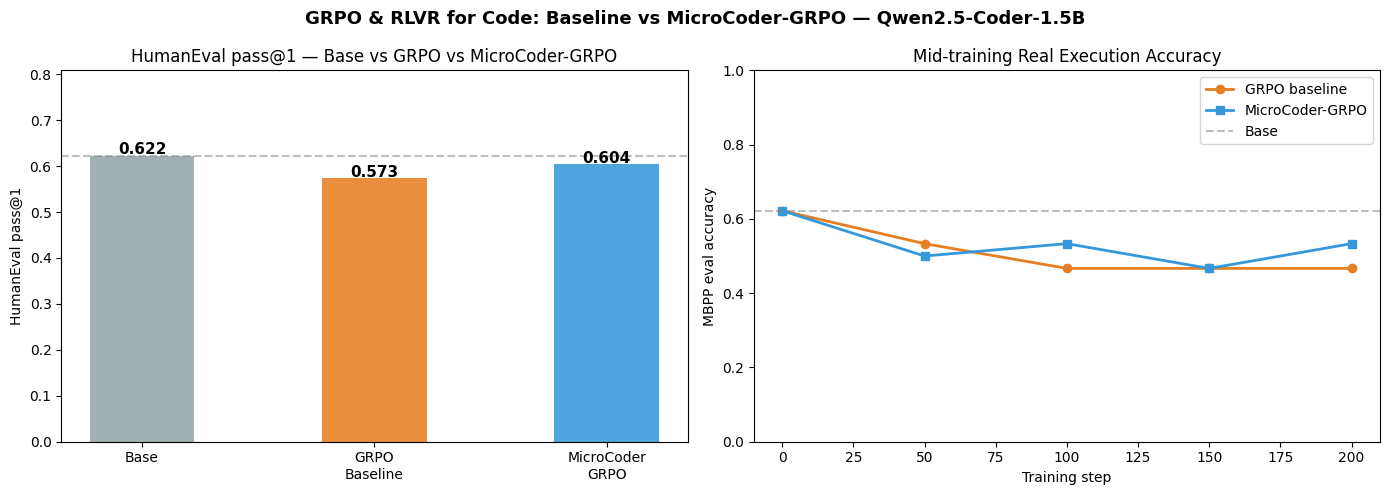

In [16]:
# ── Summary table ─────────────────────────────────────────────────────────────

print(f"{'Model':<25} {'pass@1':>8} {'Solved':>10} {'vs Base':>10}")
print("-" * 57)
for name, ev in [("Base", base_eval), ("GRPO baseline", grpo_eval), ("MicroCoder-GRPO", mc_eval)]:
    p = ev["pass@1"]
    n = len(ev["passed"])
    d = f"{p - base_eval['pass@1']:+.3f}" if name != "Base" else "—"
    print(f"{name:<25} {p:>8.3f} {n:>6}/{len(humaneval):<4} {d:>10}")

# ── Pass@1 bar chart ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = ["Base", "GRPO\nBaseline", "MicroCoder\nGRPO"]
passes = [base_eval["pass@1"], grpo_eval["pass@1"], mc_eval["pass@1"]]
colors = ["#95a5a6", "#e67e22", "#3498db"]

bars = axes[0].bar(names, passes, color=colors, width=0.45, alpha=0.88)
for bar, v in zip(bars, passes):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[0].axhline(base_eval["pass@1"], ls="--", color="gray", alpha=0.5)
axes[0].set_ylabel("HumanEval pass@1")
axes[0].set_title("HumanEval pass@1 — Base vs GRPO vs MicroCoder-GRPO")
axes[0].set_ylim(0, min(1.0, max(passes) * 1.3))

# Right: mid-training real-exec accuracy
if grpo_log["eval_steps"] and mc_log["eval_steps"]:
    axes[1].plot([0] + grpo_log["eval_steps"],
                 [base_eval["pass@1"]] + grpo_log["eval_accs"],
                 marker="o", color="#e67e22", label="GRPO baseline", lw=2)
    axes[1].plot([0] + mc_log["eval_steps"],
                 [base_eval["pass@1"]] + mc_log["eval_accs"],
                 marker="s", color="#3498db", label="MicroCoder-GRPO", lw=2)
    axes[1].axhline(base_eval["pass@1"], ls="--", color="gray", alpha=0.5, label="Base")
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("MBPP eval accuracy")
    axes[1].set_title("Mid-training Real Execution Accuracy")
    axes[1].legend()
    axes[1].set_ylim(0, 1)

plt.suptitle("GRPO & RLVR for Code: Baseline vs MicroCoder-GRPO — Qwen2.5-Coder-1.5B",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("grpo_vs_microcoder_pass_at_1.png", dpi=150)
plt.show()

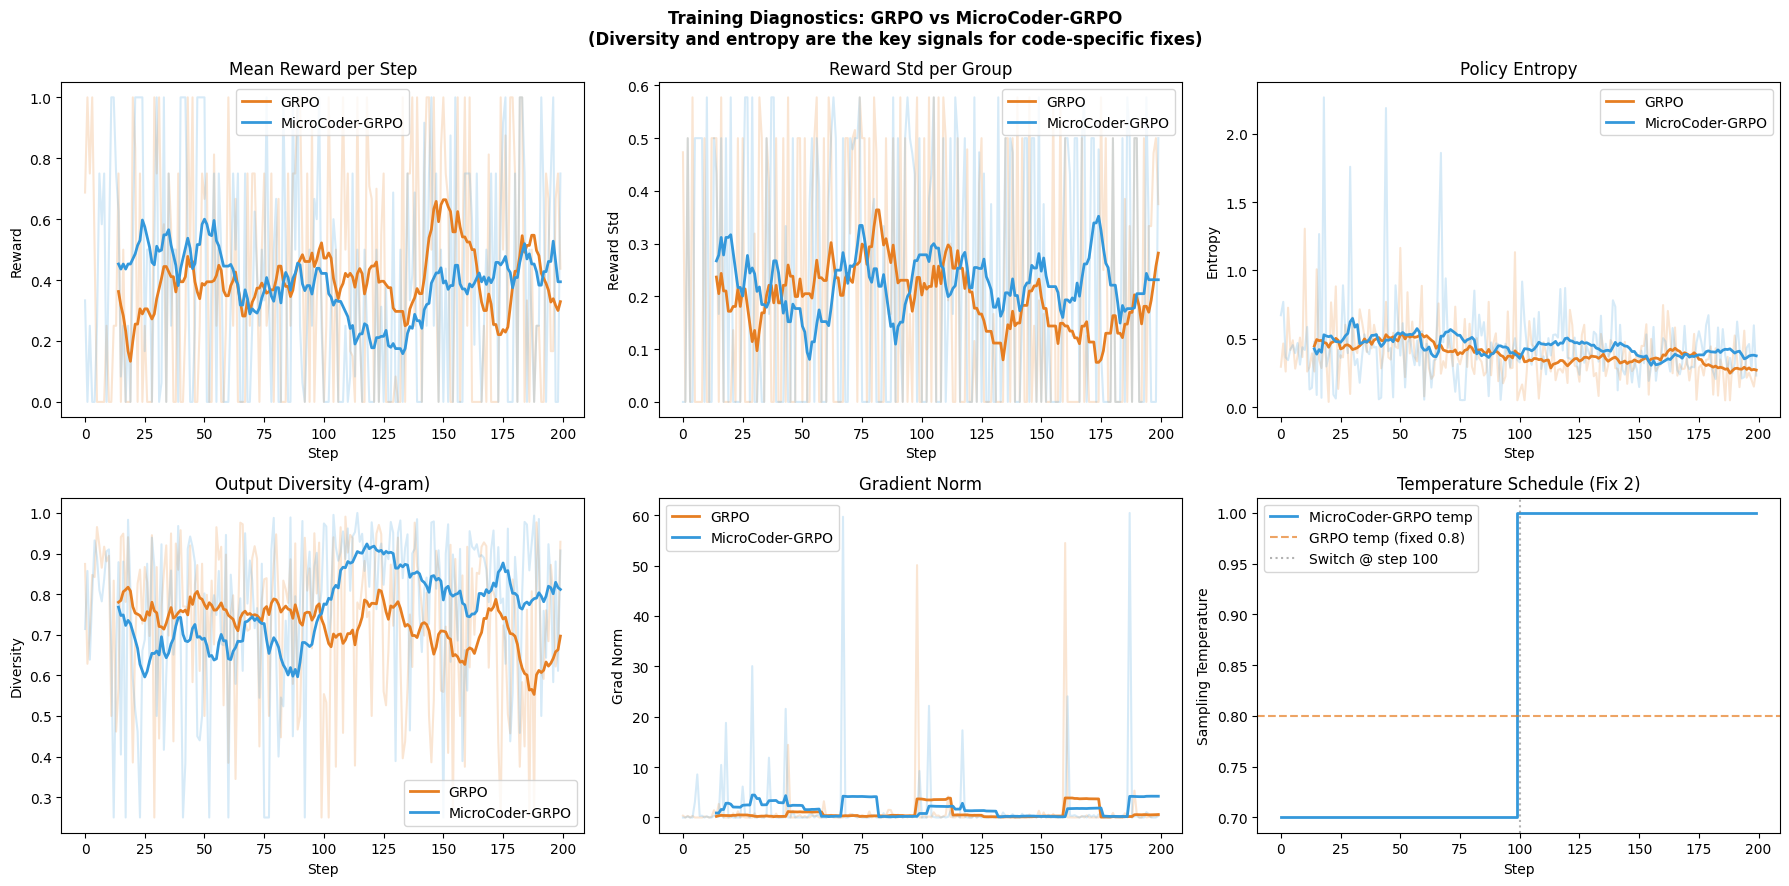

In [17]:
# ── Training diagnostics ──────────────────────────────────────────────────────

def smooth(vals, w=15):
    return np.convolve(vals, np.ones(w)/w, mode="valid")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

plot_cfg = [
    ("rewards",     "Mean Reward per Step",     "Reward",    True),
    ("reward_stds", "Reward Std per Group",      "Reward Std", True),
    ("entropies",   "Policy Entropy",            "Entropy",   True),
    ("diversities", "Output Diversity (4-gram)", "Diversity", True),
    ("grad_norms",  "Gradient Norm",             "Grad Norm", True),
]

for ax, (key, title, ylabel, do_smooth) in zip(axes[:5], plot_cfg):
    g_vals   = grpo_log[key]
    mc_vals  = mc_log[key]
    steps_g  = grpo_log["steps"]
    steps_mc = mc_log["steps"]

    ax.plot(steps_g,  g_vals,  alpha=0.2, color="#e67e22")
    ax.plot(steps_mc, mc_vals, alpha=0.2, color="#3498db")

    if do_smooth and len(g_vals) > 15:
        ax.plot(steps_g[14:],  smooth(g_vals),  color="#e67e22", lw=2, label="GRPO")
        ax.plot(steps_mc[14:], smooth(mc_vals), color="#3498db", lw=2, label="MicroCoder-GRPO")
    ax.set_title(title); ax.set_xlabel("Step"); ax.set_ylabel(ylabel)
    ax.legend()

# 6th panel: temperature schedule (Fix 2 visualised)
axes[5].step(mc_log["steps"], mc_log["temperatures"],
             color="#3498db", lw=2, label="MicroCoder-GRPO temp")
axes[5].axhline(0.8, ls="--", color="#e67e22", alpha=0.7, label="GRPO temp (fixed 0.8)")
axes[5].axvline(TEMP_SWITCH_STEP, ls=":", color="gray", alpha=0.6,
                label=f"Switch @ step {TEMP_SWITCH_STEP}")
axes[5].set_title("Temperature Schedule (Fix 2)")
axes[5].set_xlabel("Step"); axes[5].set_ylabel("Sampling Temperature")
axes[5].legend()

plt.suptitle("Training Diagnostics: GRPO vs MicroCoder-GRPO\n"
             "(Diversity and entropy are the key signals for code-specific fixes)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("grpo_vs_microcoder_diagnostics.png", dpi=150)
plt.show()

In [18]:
# ── Qualitative analysis ──────────────────────────────────────────────────────

grpo_passed = set(grpo_eval["passed"])
mc_passed   = set(mc_eval["passed"])
base_passed = set(base_eval["passed"])

mc_only    = mc_passed - grpo_passed - base_passed
grpo_only  = grpo_passed - mc_passed - base_passed
both_fixed = (mc_passed & grpo_passed) - base_passed
both_broke = (base_passed - mc_passed) & (base_passed - grpo_passed)

print(f"Problems solved by BOTH GRPO and MicroCoder-GRPO (not in base): {len(both_fixed)}")
print(f"Problems fixed by MicroCoder-GRPO only:  {len(mc_only)}")
print(f"Problems fixed by GRPO only:             {len(grpo_only)}")
print(f"Problems broken by both:                 {len(both_broke)}")

# Show one MicroCoder-only fix if available
if mc_only:
    ex_id    = list(mc_only)[0]
    problem  = next(p for p in humaneval if p["task_id"] == ex_id)
    grpo_res = next(r for r in grpo_eval["results"] if r["task_id"] == ex_id)
    mc_res   = next(r for r in mc_eval["results"]   if r["task_id"] == ex_id)

    print(f"\n{'='*65}")
    print(f"Example solved by MicroCoder-GRPO but not GRPO — {ex_id}")
    print(f"\nPrompt: {problem['prompt'][:200]}...")
    print(f"\nGRPO completion (failed):")
    print(textwrap.indent(grpo_res["completion"][:250], "  "))
    print(f"\nMicroCoder-GRPO completion (passed):")
    print(textwrap.indent(mc_res["completion"][:250], "  "))

Problems solved by BOTH GRPO and MicroCoder-GRPO (not in base): 1
Problems fixed by MicroCoder-GRPO only:  2
Problems fixed by GRPO only:             0
Problems broken by both:                 6

Example solved by MicroCoder-GRPO but not GRPO — HumanEval/114

Prompt: 
def minSubArraySum(nums):
    """
    Given an array of integers nums, find the minimum sum of any non-empty sub-array
    of nums.
    Example
    minSubArraySum([2, 3, 4, 1, 2, 4]) == 1
    minSubA...

GRPO completion (failed):
  ```python
  def minSubArraySum(nums):
      if not nums:
          return 0
    
      current_sum = max_sum = nums[0]
    
      for num in nums[1:]:
          current_sum = min(num, current_sum + num)
          max_sum = max(max_sum, current_sum)
    
      return

MicroCoder-GRPO completion (passed):
  ```python
  def minSubArraySum(nums):
      if not nums:
          return 0
    
      min_sum = float('inf')
      current_sum = 0
    
      for num in nums:
          current_sum += num
   

---
## Section 5 — Conclusions & Limitations

### What this experiment shows

**On RLVR for code:**  
Unit test execution is a clean verifiable reward signal. The interpreter is cheaper, faster, and more consistent than any reward model. Partial per-test rewards (fraction of tests passed) give gradient signal even when no completion fully solves a problem — a critical design choice for early training with a small model.

**On MicroCoder-GRPO's code-specific fixes:**  
The training diagnostics tell the story. Check the diversity and entropy plots:
- If GRPO entropy collapses but MicroCoder-GRPO's doesn't → temperature staging + high clip are working
- If output diversity (4-gram) is higher in MicroCoder-GRPO → Fix 2 (temperature) and Fix 3 (no KL) are maintaining exploration
- If truncation masking fires frequently → Fix 1 is preventing spurious penalisation of long outputs
- Temperature plot confirms Fix 2 staged correctly at step 100

**Why code-specific fixes matter:**  
DAPO (2025) diagnosed failure modes for math. MicroCoder-GRPO (2026) showed that code has fundamentally different dynamics — longer outputs, coarser reward signal, and faster capability growth that require different interventions. Math fixes applied to code may fix the wrong things.

### Limitations

**1. 200 steps is a short horizon**  
MicroCoder-GRPO's paper reports gains on LiveCodeBench after extended training.  
This experiment shows early-training dynamics, not the performance ceiling.

**2. No ablation of individual fixes**  
All 3 fixes are applied together. Isolating each requires 3 extra training runs (~4.5 hours). The diagnostics (diversity, temperature, reward curves) give directional evidence.

**3. Reward signal is still coarse**  
MBPP has only 3 test cases per problem. Even with partial per-test rewards, a group of 4 completions often gets identical reward vectors — limiting gradient signal. More test cases per problem or a syntax/runtime partial bonus would help.

**4. 1.5B policy is small**  
MicroCoder-GRPO's paper uses larger models. At 1.5B the improvement ceiling is lower, but the training dynamics (diversity, entropy, truncation rate) are fully observable.

### What V2 would look like

| Component | V1 (this notebook) | V2 |
|---|---|---|
| Steps | 200 | 2000 |
| Policy | Qwen2.5-Coder-1.5B | Qwen2.5-Coder-7B |
| Reward | Per-test partial credit | Per-test + syntax bonus (+0.1) + runtime bonus (+0.1) |
| Fix ablation | All 3 together | One at a time (3 separate runs) |
| Eval | HumanEval (164) | EvalPlus / HumanEval+ (80× more tests per problem) |
| Training data | MBPP 150 | MBPP 374 + LiveCodeBench training split |